In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

In [2]:
# 그래프의 한글 깨짐 방지
if platform.system() == 'Darwin':
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font', family = 'Malgun Gothic')

In [ ]:
df = pd.read_csv('C:\MULTICAM_11\csv\AAPL.csv')
df.info()

In [ ]:
df2 = pd.read_csv('C:\MULTICAM_11\csv\AAPL.csv', usecols = ['Date', 'Adj Close'])
df2.info()

In [ ]:
df[['Date', 'Adj Close']]

In [ ]:
df2

In [8]:
# 결측치가 포함된 인덱스를 제거 -> 제거, 삭제(drop), 결측치(na)
df2.dropna(inplace = True)

In [9]:
# 시계열 변경
df2['Date'] = pd.to_datetime(df2['Date'])

In [ ]:
df2.head(3)

In [ ]:
df2.info()

<Axes: xlabel='Date'>

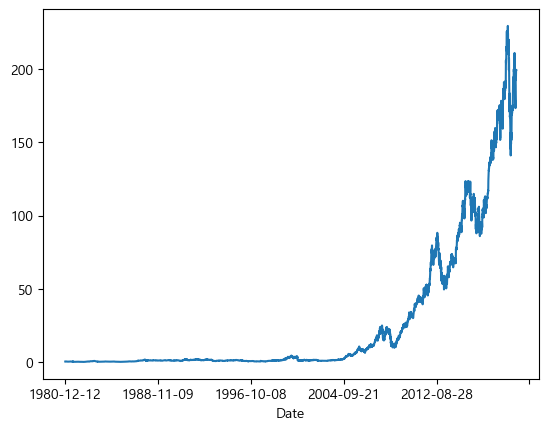

In [21]:
df.set_index('Date')['Adj Close'].plot()

In [13]:
# Date 컬럼을 인덱스로 전환
df2.set_index('Date', inplace=True)

- 이동평균선
    - n(5, 20, 60, 120)일 치의 주가의 평균을 구한다.

In [14]:
# 인덱스를 n(20)개씩 묶어서 Adj Close 평균을 구한다.
df2.iloc[0:20, 0].mean()
df2.iloc[1:21, 0].mean()

np.float64(0.4445271)

In [15]:
# 이동평균값 컬럼을 먼저 생성 -> 데이터는 0을 대입
df2['이동평균값'] = 0

In [16]:
df2.iloc[19,1] = df2.iloc[0:20, 0].mean()

C:\Users\신재호\AppData\Local\Temp\ipykernel_31168\1134071932.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4432777' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df2.iloc[19,1] = df2.iloc[0:20, 0].mean()


In [17]:
# 반복횟수는?
for i in range(len(df2)-19):
    df2.iloc[i+19,1] = df2.iloc[i:i+20,0].mean()

In [18]:
df2.tail()

,Adj Close,이동평균값
Date,,
2019-06-18,198.449997,185.4325
2019-06-19,197.869995,185.9960
2019-06-20,199.460007,186.8300
2019-06-21,198.779999,187.7860
2019-06-24,199.169998,188.7960


In [19]:
# 인덱스끼리 묶어서 연산을 해주는 함수가 존재, rolling(n)
df2['Adj Close'].rolling(20).mean().fillna(0)

Date
1980-12-12      0.0000
1980-12-15      0.0000
1980-12-16      0.0000
1980-12-17      0.0000
1980-12-18      0.0000
                ...   
2019-06-18    185.4325
2019-06-19    185.9960
2019-06-20    186.8300
2019-06-21    187.7860
2019-06-24    188.7960
Name: Adj Close, Length: 9714, dtype: float64

<Axes: xlabel='Date'>

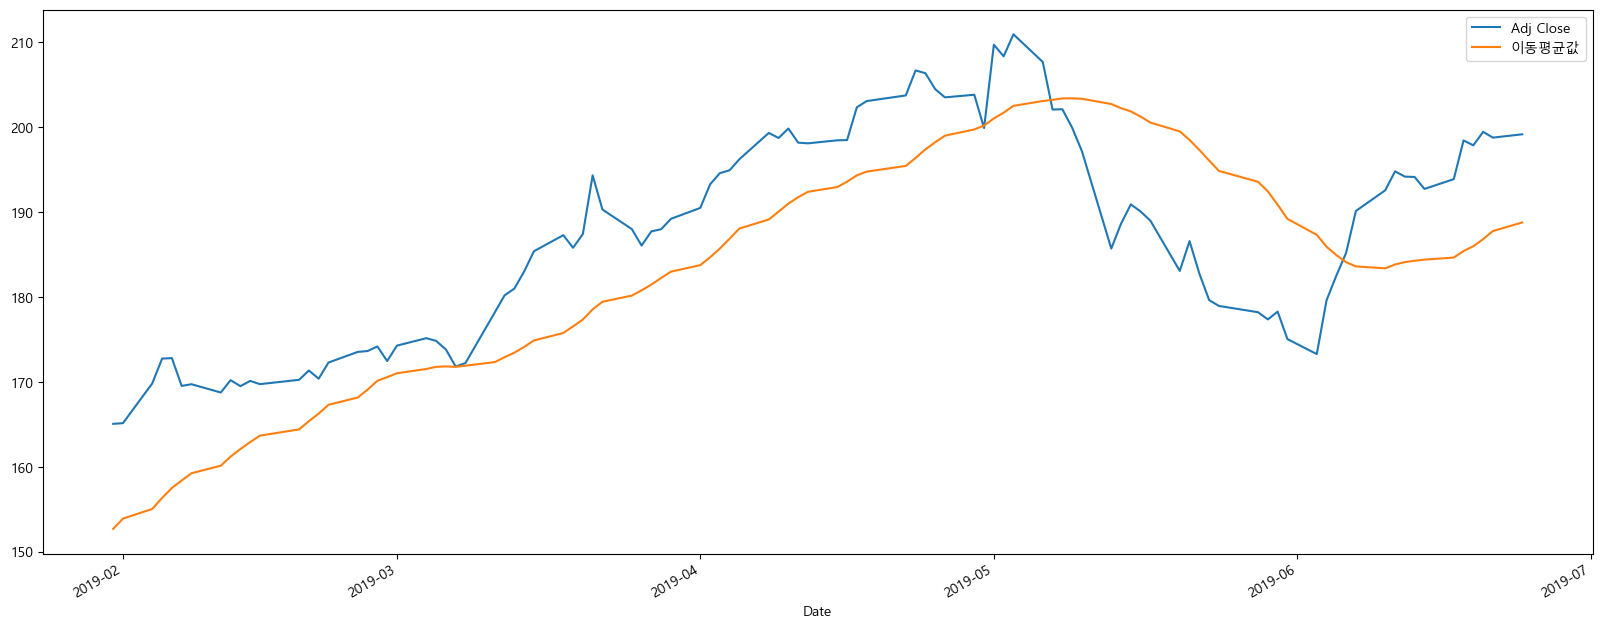

In [19]:
df2[['Adj Close', '이동평균값']].tail(100).plot(figsize=(20, 8))

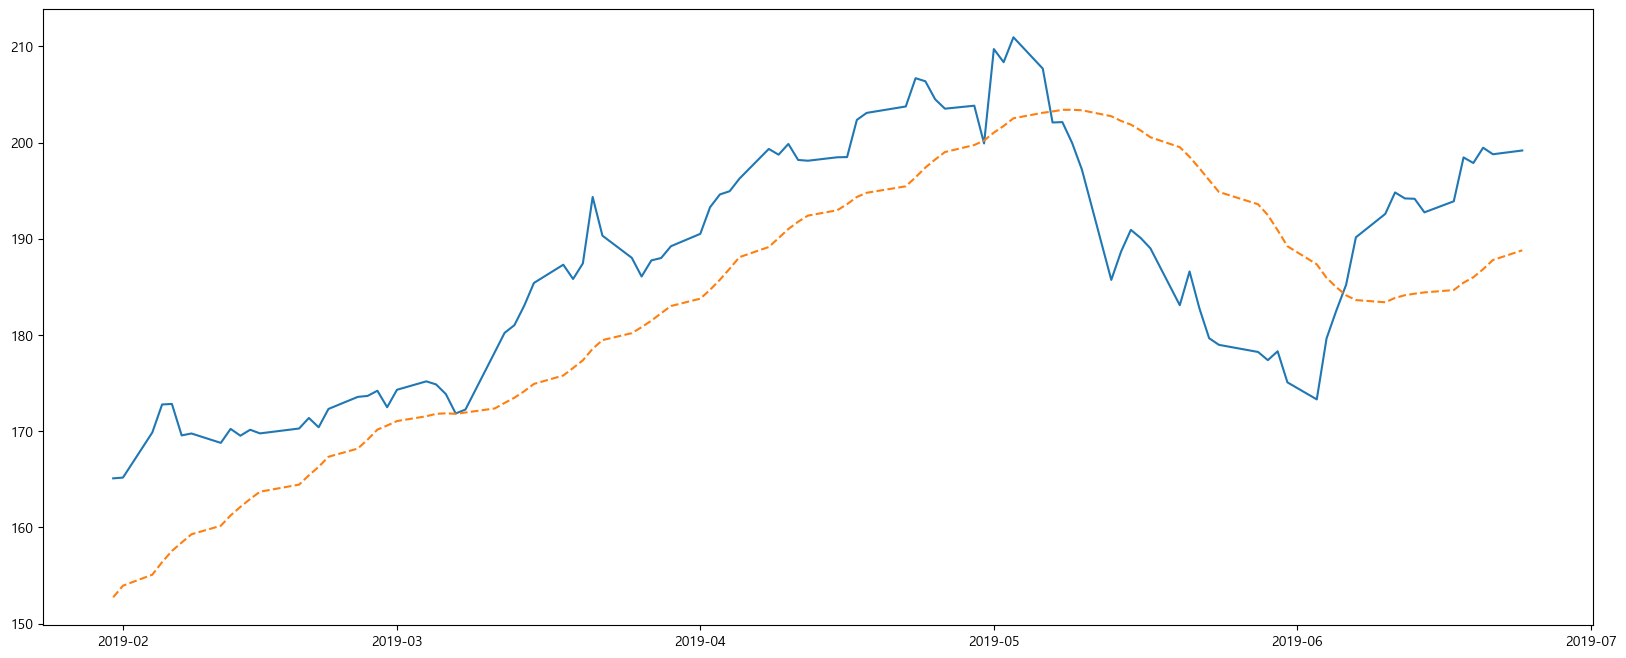

In [22]:
plt.figure(figsize=(20, 8))
plt.plot(df2.tail(100)['Adj Close'])
# 선의 종류를 대쉬 선으로 변경
plt.plot(df2.tail(100)['이동평균값'] ,'--')
plt.show()

- 상단 밴드, 하단 밴드
    - 상단밴드 -> 20일 이동평균선 + ( 2 * 20일 표준편차)
    - 하단밴드 -> 20일 이동평균선 - ( 2 * 20일 표준편차)

In [22]:
df2['ub'] = df2['이동평균값'] + ( 2 * df2['Adj Close'].rolling(20).std())
df2['lb'] = df2['이동평균값'] - ( 2 * df2['Adj Close'].rolling(20).std())

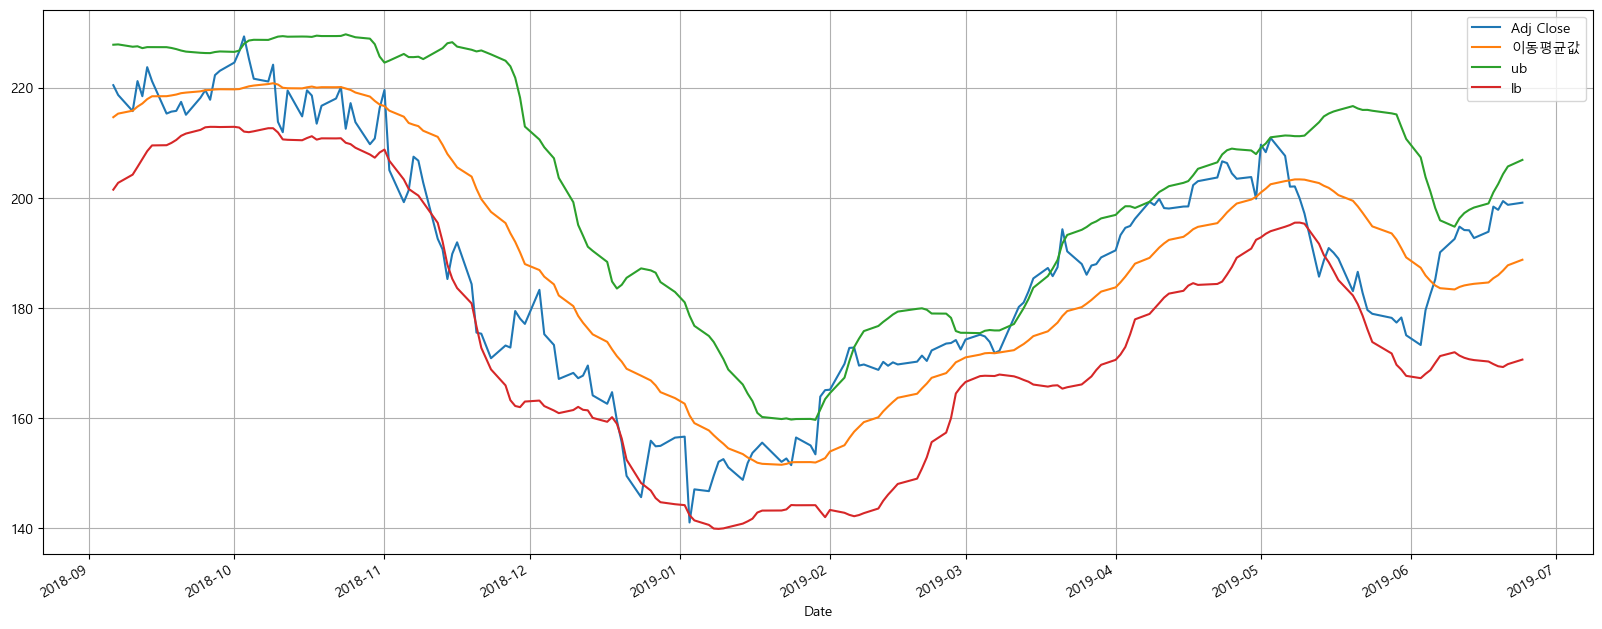

In [29]:
# 최근 100일치 데이터에서 상단밴드, 하단밴드, 이동평균선, 종가 그래프에 출력
df2.tail(200).plot(figsize=(20, 8))
plt.grid(True)